# Module 13.3: Model Quantization Comparison

**Focus**: Comparing models with different quantization (CPU-optimized)

## What is Quantization?

**Quantization** is a technique to reduce the numerical precision of model parameters:

- **FP32** (Float32): Standard precision, 32 bits per parameter
- **FP16** (Float16): Half precision, 16 bits per parameter
- **INT8**: 8-bit integers, massive compression
- **INT4**: Extreme compression, significant quality loss

**Advantages**: Less memory, faster inference, deployment on limited devices  
**Disadvantages**: Potential quality degradation

In [1]:
# Install dependencies (run only once)
!pip install transformers torch bitsandbytes accelerate
!pip install matplotlib seaborn pandas numpy psutil
!pip install sacrebleu rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.7 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b97ab7e37762922c2efda45c4edbdc4ec0e681316e026ca8a7941952b5047ae2
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import os
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
from sacrebleu import sentence_bleu
from rouge_score import rouge_scorer
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check hardware
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CPU cores: {psutil.cpu_count()}")
print(f"RAM available: {psutil.virtual_memory().available / (1024**3):.1f} GB")

PyTorch version: 2.10.0+cpu
CUDA available: False
CPU cores: 2
RAM available: 10.0 GB


## 1. Test Dataset Preparation

Let's create a set of diverse prompts to test generation quality.

In [3]:
# Test dataset with different task types
test_prompts = [
    {
        "category": "Creative Writing",
        "prompt": "Write a short story about a robot learning to paint:",
        "expected_style": "narrative, descriptive"
    },
    {
        "category": "Technical Explanation",
        "prompt": "Explain how neural networks work in simple terms:",
        "expected_style": "clear, educational"
    },
    {
        "category": "Code Generation",
        "prompt": "Write a Python function to calculate fibonacci numbers:",
        "expected_style": "precise, syntactic"
    },
    {
        "category": "Reasoning",
        "prompt": "If it takes 5 machines 5 minutes to make 5 widgets, how long would it take 100 machines to make 100 widgets?",
        "expected_style": "logical, step-by-step"
    },
    {
        "category": "Summary",
        "prompt": "Summarize the main benefits of renewable energy:",
        "expected_style": "concise, informative"
    },
    {
        "category": "Translation",
        "prompt": "Translate to Italian: The weather is beautiful today and perfect for a walk in the park.",
        "expected_style": "accurate, natural"
    }
]

print(f"Prepared {len(test_prompts)} test prompts covering different domains:")
for prompt in test_prompts:
    print(f"- {prompt['category']}: {prompt['expected_style']}")

Prepared 6 test prompts covering different domains:
- Creative Writing: narrative, descriptive
- Technical Explanation: clear, educational
- Code Generation: precise, syntactic
- Reasoning: logical, step-by-step
- Summary: concise, informative
- Translation: accurate, natural


## 2. Benchmarking Utility Functions

In [4]:
def get_model_size_mb(model):
    """Calculate model size in MB"""
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    return (param_size + buffer_size) / (1024**2)

def measure_memory_usage():
    """Measure current memory usage"""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024**2)  # MB

def generate_with_timing(model, tokenizer, prompt, max_length=100, **kwargs):
    """Generate text while measuring time and memory"""
    inputs = tokenizer(prompt, return_tensors="pt")

    # Memory before
    mem_before = measure_memory_usage()

    # Generation with timing
    start_time = time.time()

    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            max_length=max_length,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
            **kwargs
        )

    end_time = time.time()

    # Memory after
    mem_after = measure_memory_usage()

    # Decode
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response_only = generated_text.replace(prompt, "").strip()

    return {
        'text': response_only,
        'generation_time': end_time - start_time,
        'memory_used': mem_after - mem_before,
        'tokens_generated': len(outputs[0]) - len(inputs.input_ids[0])
    }

def calculate_text_metrics(text):
    """Calculate basic text metrics"""
    words = text.split()
    sentences = text.split('.')

    return {
        'word_count': len(words),
        'sentence_count': len([s for s in sentences if s.strip()]),
        'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
        'vocabulary_richness': len(set(words)) / len(words) if words else 0
    }

print("Utility functions defined successfully!")

Utility functions defined successfully!


## 3. Loading Models with Different Quantizations

We'll load the same model (DistilGPT-2) with different precisions for comparison.

In [5]:
# Choose DistilGPT-2 to be gentle on CPU
model_name = "distilgpt2"  # ~82M parameters, lighter than GPT-2

# Load tokenizer (same for all)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

models = {}

print("Loading models with different quantizations...")

# 1. FP32 model (full precision)
print("\n1. Loading FP32 model...")
models['FP32'] = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float32,
    device_map="cpu"
)
print(f"   Size: {get_model_size_mb(models['FP32']):.1f} MB")

# 2. FP16 model (half precision) - if supported
print("\n2. Loading FP16 model...")
try:
    models['FP16'] = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="cpu"
    )
    print(f"   Size: {get_model_size_mb(models['FP16']):.1f} MB")
except Exception as e:
    print(f"   FP16 not supported on CPU, using FP32 instead")
    models['FP16'] = models['FP32']  # Fallback

# 3. INT8 model (8-bit quantization)
print("\n3. Loading INT8 model...")
try:
    quantization_config = BitsAndBytesConfig(
        load_in_8bit=True,
        llm_int8_enable_fp32_cpu_offload=True
    )
    models['INT8'] = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quantization_config,
        device_map="auto"
    )
    print(f"   Size: {get_model_size_mb(models['INT8']):.1f} MB (estimated)")
except Exception as e:
    print(f"   INT8 quantization failed: {e}")
    print(f"   Using FP32 model as fallback")
    models['INT8'] = models['FP32']  # Fallback

print(f"\nSuccessfully loaded {len(models)} model variants:")
for name, model in models.items():
    print(f"- {name}: {get_model_size_mb(model):.1f} MB")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Size: 162.2 MB

3. Loading INT8 model...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Size: 197.0 MB (estimated)

Successfully loaded 3 model variants:
- FP32: 318.5 MB
- FP16: 162.2 MB
- INT8: 197.0 MB


## 4. Performance Benchmarking

Let's test each model on all prompts and measure performance.

In [6]:
# Run comprehensive benchmark
results = []

print("Starting comprehensive benchmark...")
print("This may take several minutes on CPU.\n")

for model_name, model in models.items():
    print(f"Testing {model_name} model...")

    for i, test_case in enumerate(test_prompts):
        print(f"  - {test_case['category']} ({i+1}/{len(test_prompts)})")

        # Generate with timing
        generation_result = generate_with_timing(
            model, tokenizer,
            test_case['prompt'],
            max_length=150
        )

        # Calculate text metrics
        text_metrics = calculate_text_metrics(generation_result['text'])

        # Combine all results
        result = {
            'model': model_name,
            'category': test_case['category'],
            'prompt': test_case['prompt'][:50] + '...',
            'generated_text': generation_result['text'][:100] + '...',
            'generation_time': generation_result['generation_time'],
            'memory_used': generation_result['memory_used'],
            'tokens_generated': generation_result['tokens_generated'],
            'tokens_per_second': generation_result['tokens_generated'] / generation_result['generation_time'],
            **text_metrics
        }

        results.append(result)

        # Brief pause for stability
        time.sleep(0.5)

print("\nBenchmark completed!")
print(f"Total results: {len(results)}")

# Convert to DataFrame for analysis
df = pd.DataFrame(results)
print("\nFirst few results:")
print(df[['model', 'category', 'generation_time', 'tokens_per_second', 'word_count']].head())

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Starting comprehensive benchmark...
This may take several minutes on CPU.

Testing FP32 model...
  - Creative Writing (1/6)
  - Technical Explanation (2/6)
  - Code Generation (3/6)
  - Reasoning (4/6)
  - Summary (5/6)
  - Translation (6/6)
Testing FP16 model...
  - Creative Writing (1/6)
  - Technical Explanation (2/6)
  - Code Generation (3/6)
  - Reasoning (4/6)
  - Summary (5/6)
  - Translation (6/6)
Testing INT8 model...
  - Creative Writing (1/6)
  - Technical Explanation (2/6)
  - Code Generation (3/6)
  - Reasoning (4/6)
  - Summary (5/6)
  - Translation (6/6)

Benchmark completed!
Total results: 18

First few results:
  model               category  generation_time  tokens_per_second  word_count
0  FP32       Creative Writing        11.037214          12.593757           5
1  FP32  Technical Explanation        10.625207          13.176214           0
2  FP32        Code Generation         9.443506          14.719110           0
3  FP32              Reasoning         8.999951 

## 5. Performance Analysis: Speed and Efficiency

=== PERFORMANCE STATISTICS BY MODEL ===
       generation_time_mean  generation_time_std  tokens_per_second_mean  \
model                                                                      
FP16                 29.536                5.771                   4.752   
FP32                  9.184                4.724                  12.673   
INT8                 11.592                0.299                  11.714   

       tokens_per_second_std  memory_used_mean  memory_used_std  \
model                                                             
FP16                   0.975             0.117            0.228   
FP32                   1.798            52.663          128.987   
INT8                   0.217            24.721           60.549   

       word_count_mean  word_count_std  vocabulary_richness_mean  \
model                                                              
FP16            31.667          48.903                     0.238   
FP32            14.500          32.636 

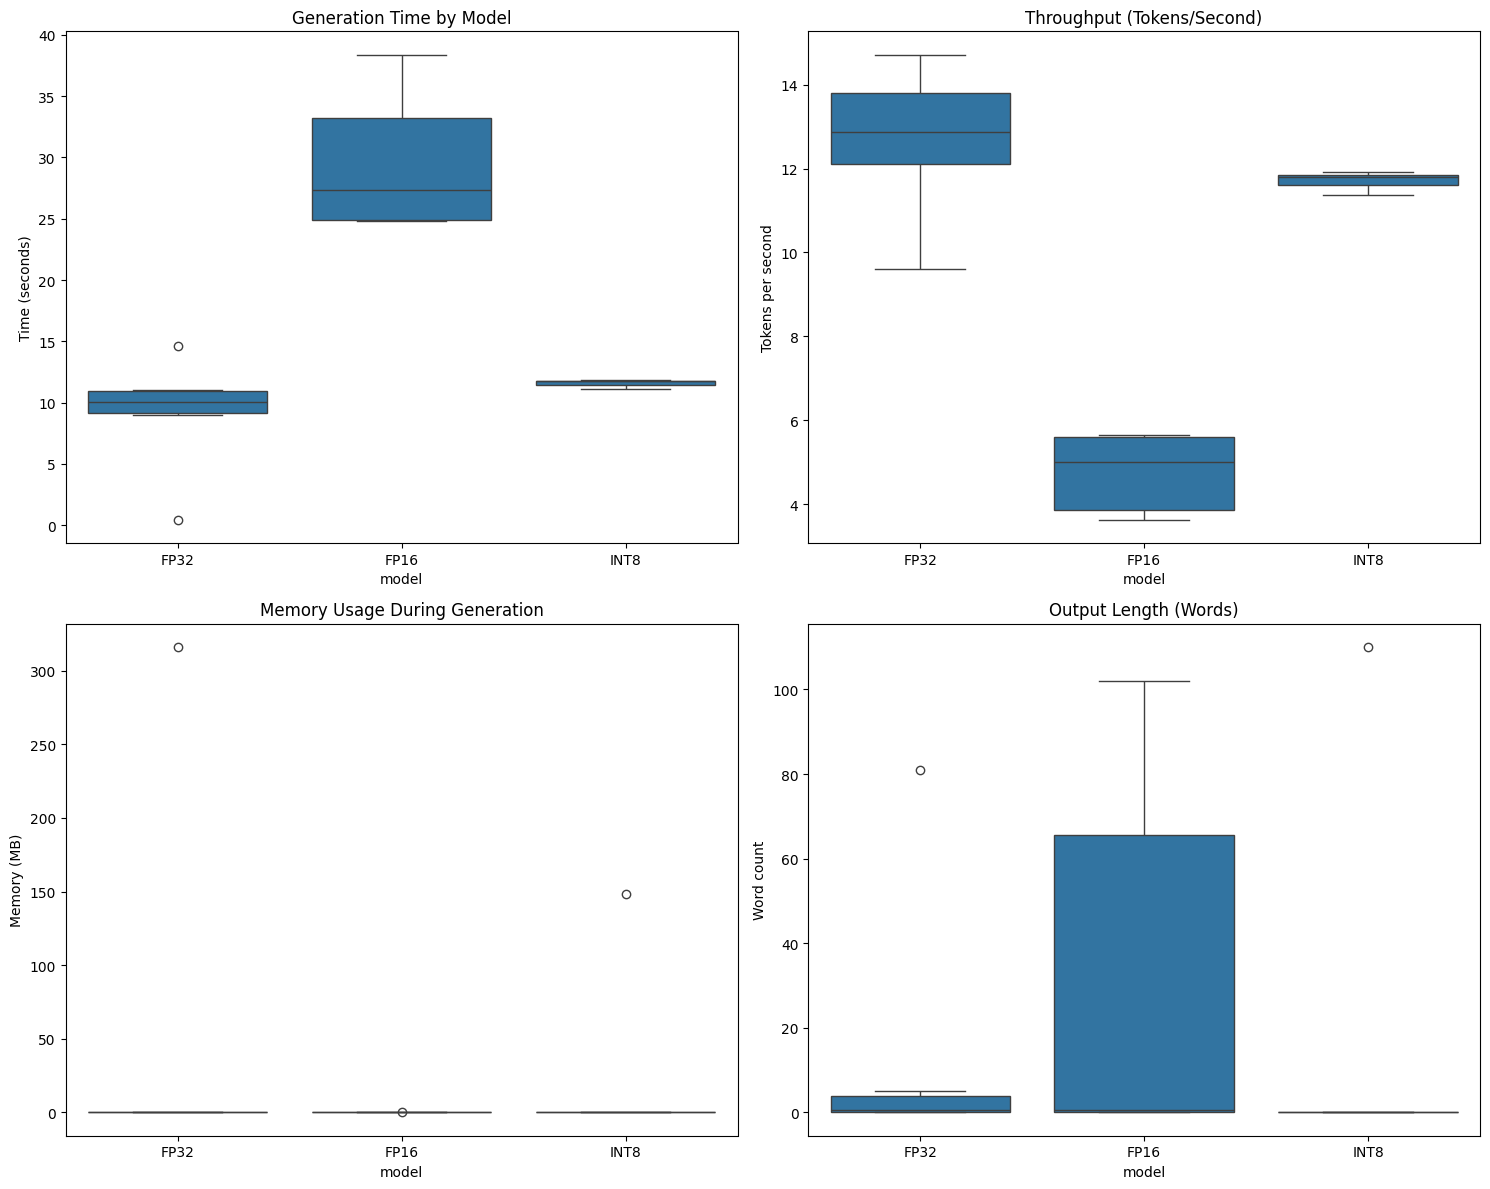


=== EFFICIENCY COMPARISON ===
       generation_time_mean  tokens_per_second_mean  memory_used_mean  \
model                                                                   
FP16                 29.536                   4.752             0.117   
INT8                 11.592                  11.714            24.721   
FP32                  9.184                  12.673            52.663   

       efficiency_score  
model                    
FP16           0.160888  
INT8           0.040877  
FP32           0.026202  


In [7]:
# Calculate statistics by model
model_stats = df.groupby('model').agg({
    'generation_time': ['mean', 'std'],
    'tokens_per_second': ['mean', 'std'],
    'memory_used': ['mean', 'std'],
    'word_count': ['mean', 'std'],
    'vocabulary_richness': ['mean', 'std']
}).round(3)

model_stats.columns = ['_'.join(col).strip() for col in model_stats.columns]

print("=== PERFORMANCE STATISTICS BY MODEL ===")
print(model_stats)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Generation time
sns.boxplot(data=df, x='model', y='generation_time', ax=axes[0,0])
axes[0,0].set_title('Generation Time by Model')
axes[0,0].set_ylabel('Time (seconds)')

# 2. Tokens per second
sns.boxplot(data=df, x='model', y='tokens_per_second', ax=axes[0,1])
axes[0,1].set_title('Throughput (Tokens/Second)')
axes[0,1].set_ylabel('Tokens per second')

# 3. Memory usage
sns.boxplot(data=df, x='model', y='memory_used', ax=axes[1,0])
axes[1,0].set_title('Memory Usage During Generation')
axes[1,0].set_ylabel('Memory (MB)')

# 4. Output length
sns.boxplot(data=df, x='model', y='word_count', ax=axes[1,1])
axes[1,1].set_title('Output Length (Words)')
axes[1,1].set_ylabel('Word count')

plt.tight_layout()
plt.show()

# Efficiency comparison
efficiency_comparison = model_stats[['generation_time_mean', 'tokens_per_second_mean', 'memory_used_mean']].copy()
efficiency_comparison['efficiency_score'] = (
    efficiency_comparison['tokens_per_second_mean'] /
    (efficiency_comparison['generation_time_mean'] * efficiency_comparison['memory_used_mean'].clip(lower=1))
)

print("\n=== EFFICIENCY COMPARISON ===")
print(efficiency_comparison.sort_values('efficiency_score', ascending=False))

## 6. Qualitative Analysis: Output Comparison

=== QUALITY METRICS BY CATEGORY AND MODEL ===
                             word_count  vocabulary_richness  avg_word_length  \
category              model                                                     
Code Generation       FP16          0.0                0.000            0.000   
                      FP32          0.0                0.000            0.000   
                      INT8          0.0                0.000            0.000   
Creative Writing      FP16          1.0                1.000          305.000   
                      FP32          5.0                1.000            4.800   
                      INT8          0.0                0.000            0.000   
Reasoning             FP16         87.0                0.322            3.931   
                      FP32         81.0                0.506            3.877   
                      INT8        110.0                0.336            3.236   
Summary               FP16          0.0                0.000   

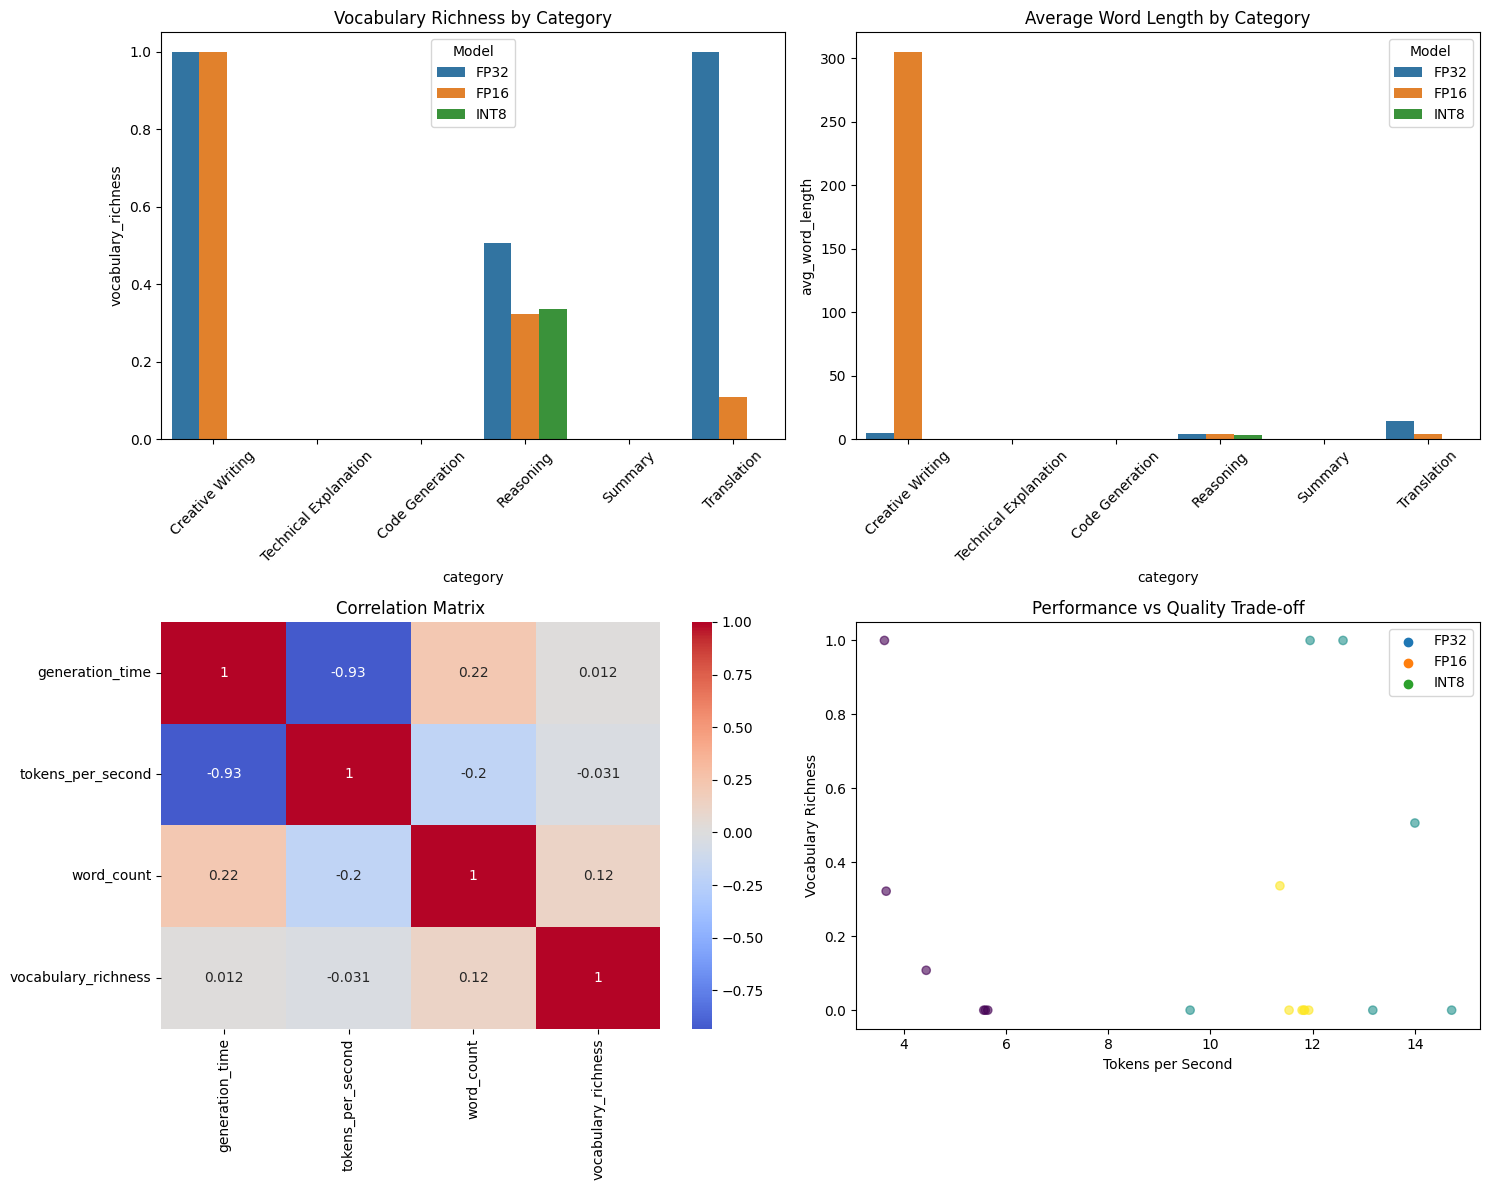

In [8]:
# Analyze quality by task category
quality_by_category = df.groupby(['category', 'model']).agg({
    'word_count': 'mean',
    'vocabulary_richness': 'mean',
    'avg_word_length': 'mean',
    'sentence_count': 'mean'
}).round(3)

print("=== QUALITY METRICS BY CATEGORY AND MODEL ===")
print(quality_by_category)

# Visualize qualitative differences
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Vocabulary richness by category
sns.barplot(data=df, x='category', y='vocabulary_richness', hue='model', ax=axes[0,0])
axes[0,0].set_title('Vocabulary Richness by Category')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(title='Model')

# 2. Average word length
sns.barplot(data=df, x='category', y='avg_word_length', hue='model', ax=axes[0,1])
axes[0,1].set_title('Average Word Length by Category')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Model')

# 3. Correlation heatmap
correlation_matrix = df[['generation_time', 'tokens_per_second', 'word_count', 'vocabulary_richness']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,0])
axes[1,0].set_title('Correlation Matrix')

# 4. Performance vs Quality scatter
axes[1,1].scatter(df['tokens_per_second'], df['vocabulary_richness'],
                  c=df['model'].astype('category').cat.codes, alpha=0.6)
axes[1,1].set_xlabel('Tokens per Second')
axes[1,1].set_ylabel('Vocabulary Richness')
axes[1,1].set_title('Performance vs Quality Trade-off')

# Add legend for scatter
for i, model in enumerate(df['model'].unique()):
    axes[1,1].scatter([], [], c=f'C{i}', label=model)
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 7. Side-by-Side Output Examples

In [9]:
# Choose a prompt for detailed comparison
example_category = "Creative Writing"
example_outputs = df[df['category'] == example_category]

print(f"=== SIDE-BY-SIDE COMPARISON: {example_category} ===")
print(f"Prompt: {test_prompts[0]['prompt']}\n")

for _, row in example_outputs.iterrows():
    print(f"**{row['model']} Model:**")
    print(f"Generated: {row['generated_text']}")
    print(f"Time: {row['generation_time']:.2f}s | Tokens/s: {row['tokens_per_second']:.1f} | Words: {row['word_count']}")
    print(f"Vocabulary richness: {row['vocabulary_richness']:.3f}\n")
    print("-" * 80 + "\n")

# Technical comparison
print("=== TECHNICAL COMPARISON ===")
technical_category = "Code Generation"
tech_outputs = df[df['category'] == technical_category]

for _, row in tech_outputs.iterrows():
    print(f"**{row['model']} - Code Generation:**")
    print(f"{row['generated_text']}")
    print(f"Performance: {row['tokens_per_second']:.1f} tok/s\n")


=== SIDE-BY-SIDE COMPARISON: Creative Writing ===
Prompt: Write a short story about a robot learning to paint:

**FP32 Model:**
Generated: The Robot Learning to Paint....
Time: 11.04s | Tokens/s: 12.6 | Words: 5
Vocabulary richness: 1.000

--------------------------------------------------------------------------------

**FP16 Model:**
Generated: http://www.digitaljournal.com/articles/2012/10/20/bot-learns-to-make-a-truck-silly-truck-learned-to-...
Time: 38.40s | Tokens/s: 3.6 | Words: 1
Vocabulary richness: 1.000

--------------------------------------------------------------------------------

**INT8 Model:**
Generated: ...
Time: 11.79s | Tokens/s: 11.8 | Words: 0
Vocabulary richness: 0.000

--------------------------------------------------------------------------------

=== TECHNICAL COMPARISON ===
**FP32 - Code Generation:**
...
Performance: 14.7 tok/s

**FP16 - Code Generation:**
...
Performance: 5.6 tok/s

**INT8 - Code Generation:**
...
Performance: 11.8 tok/s



## 8. Trade-off Analysis and Recommendations

In [10]:
# Calculate overall score for each model
def calculate_overall_score(row):
    # Normalize metrics (0-1 scale)
    speed_score = (row['tokens_per_second_mean'] - df.groupby('model')['tokens_per_second'].mean().min()) / \
                  (df.groupby('model')['tokens_per_second'].mean().max() - df.groupby('model')['tokens_per_second'].mean().min())

    quality_score = (row['vocabulary_richness_mean'] - model_stats['vocabulary_richness_mean'].min()) / \
                    (model_stats['vocabulary_richness_mean'].max() - model_stats['vocabulary_richness_mean'].min())

    # Memory efficiency (inverse)
    memory_score = 1 - ((row['memory_used_mean'] - model_stats['memory_used_mean'].min()) / \
                       (model_stats['memory_used_mean'].max() - model_stats['memory_used_mean'].min()))

    # Combined score (equal weight)
    return (speed_score + quality_score + memory_score) / 3

model_rankings = model_stats.copy()
model_rankings['overall_score'] = model_rankings.apply(calculate_overall_score, axis=1)
model_rankings = model_rankings.sort_values('overall_score', ascending=False)

print("=== OVERALL MODEL RANKING ===")
print(model_rankings[['generation_time_mean', 'tokens_per_second_mean', 'vocabulary_richness_mean', 'overall_score']].round(3))

# Use case recommendations
recommendations = []

for model in models.keys():
    model_data = model_stats.loc[model]

    use_cases = []

    if model_data['tokens_per_second_mean'] > model_stats['tokens_per_second_mean'].median():
        use_cases.append("High-throughput applications")

    if model_data['memory_used_mean'] < model_stats['memory_used_mean'].median():
        use_cases.append("Resource-constrained environments")

    if model_data['vocabulary_richness_mean'] > model_stats['vocabulary_richness_mean'].median():
        use_cases.append("Creative/diverse content generation")

    if model_data['generation_time_mean'] < model_stats['generation_time_mean'].median():
        use_cases.append("Real-time applications")

    recommendations.append({
        'model': model,
        'best_for': ', '.join(use_cases) if use_cases else 'Baseline comparison',
        'overall_score': model_rankings.loc[model, 'overall_score']
    })

rec_df = pd.DataFrame(recommendations).sort_values('overall_score', ascending=False)

print("\n=== USE CASE RECOMMENDATIONS ===")
for _, row in rec_df.iterrows():
    print(f"**{row['model']}** (Score: {row['overall_score']:.3f})")
    print(f"  Best for: {row['best_for']}\n")

# Final summary
print("=== KEY INSIGHTS ===")
fastest_model = model_stats['tokens_per_second_mean'].idxmax()
most_efficient = model_stats['memory_used_mean'].idxmin()
highest_quality = model_stats['vocabulary_richness_mean'].idxmax()

print(f"🚀 Fastest generation: {fastest_model} ({model_stats.loc[fastest_model, 'tokens_per_second_mean']:.1f} tok/s)")
print(f"💾 Most memory efficient: {most_efficient} ({model_stats.loc[most_efficient, 'memory_used_mean']:.1f} MB)")
print(f"✨ Highest vocabulary richness: {highest_quality} ({model_stats.loc[highest_quality, 'vocabulary_richness_mean']:.3f})")
print(f"🏆 Best overall: {rec_df.iloc[0]['model']} (balanced performance)")

=== OVERALL MODEL RANKING ===
       generation_time_mean  tokens_per_second_mean  vocabulary_richness_mean  \
model                                                                           
FP32                  9.184                  12.673                     0.418   
FP16                 29.536                   4.752                     0.238   
INT8                 11.592                  11.714                     0.056   

       overall_score  
model                 
FP32           0.667  
FP16           0.501  
INT8           0.470  

=== USE CASE RECOMMENDATIONS ===
**FP32** (Score: 0.667)
  Best for: High-throughput applications, Creative/diverse content generation, Real-time applications

**FP16** (Score: 0.501)
  Best for: Resource-constrained environments

**INT8** (Score: 0.470)
  Best for: Baseline comparison

=== KEY INSIGHTS ===
🚀 Fastest generation: FP32 (12.7 tok/s)
💾 Most memory efficient: FP16 (0.1 MB)
✨ Highest vocabulary richness: FP32 (0.418)
🏆 Best overall: 

## 9. Final Visualization: Comparative Dashboard

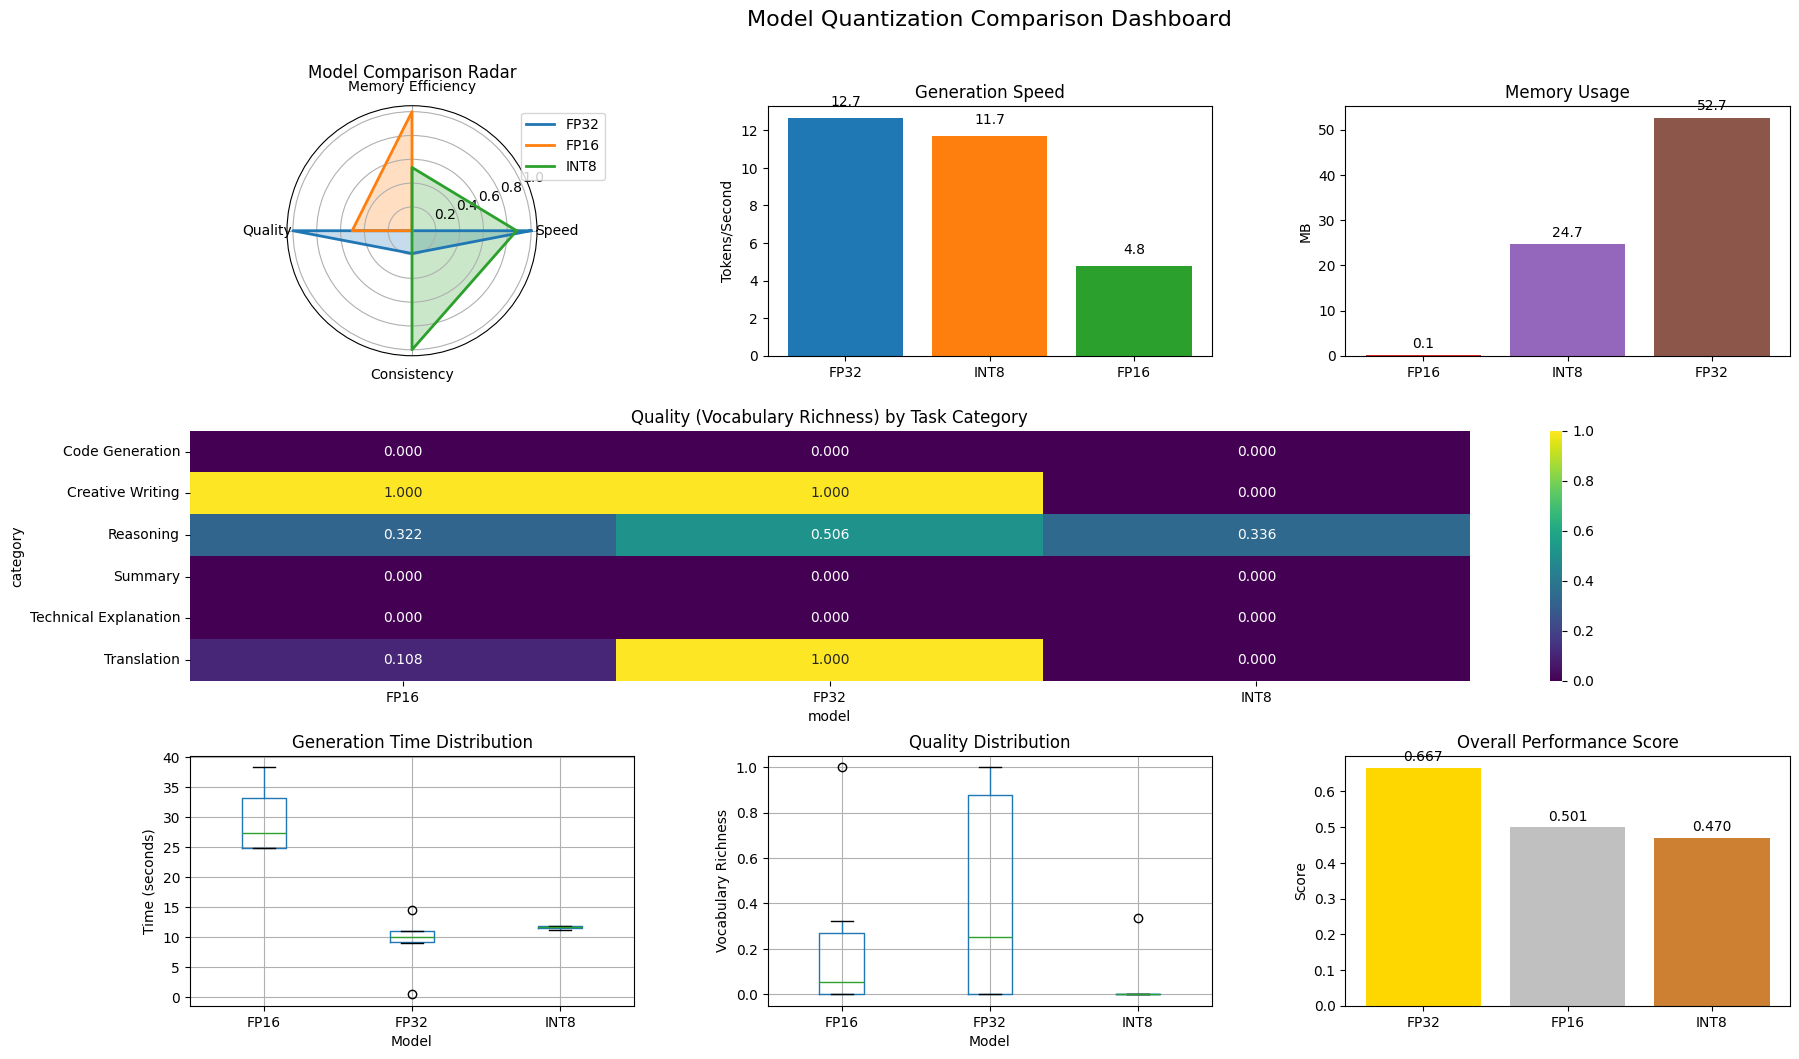

In [11]:
# Final dashboard with all key metrics
fig = plt.figure(figsize=(20, 12))

# 3x3 grid
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Radar chart for each model
ax1 = fig.add_subplot(gs[0, 0], projection='polar')
categories = ['Speed', 'Memory Efficiency', 'Quality', 'Consistency']
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

for model in models.keys():
    values = [
        (model_stats.loc[model, 'tokens_per_second_mean'] - model_stats['tokens_per_second_mean'].min()) /
        (model_stats['tokens_per_second_mean'].max() - model_stats['tokens_per_second_mean'].min()),
        1 - (model_stats.loc[model, 'memory_used_mean'] - model_stats['memory_used_mean'].min()) /
        (model_stats['memory_used_mean'].max() - model_stats['memory_used_mean'].min()),
        (model_stats.loc[model, 'vocabulary_richness_mean'] - model_stats['vocabulary_richness_mean'].min()) /
        (model_stats['vocabulary_richness_mean'].max() - model_stats['vocabulary_richness_mean'].min()),
        1 - (model_stats.loc[model, 'generation_time_std'] - model_stats['generation_time_std'].min()) /
        (model_stats['generation_time_std'].max() - model_stats['generation_time_std'].min())
    ]
    values += values[:1]  # Complete the circle

    ax1.plot(angles, values, label=model, linewidth=2)
    ax1.fill(angles, values, alpha=0.25)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)
ax1.set_title('Model Comparison Radar', y=1.08)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

# 2. Speed comparison bar
ax2 = fig.add_subplot(gs[0, 1])
speed_data = model_stats['tokens_per_second_mean'].sort_values(ascending=False)
bars = ax2.bar(speed_data.index, speed_data.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Generation Speed')
ax2.set_ylabel('Tokens/Second')
for bar, value in zip(bars, speed_data.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{value:.1f}',
             ha='center', va='bottom')

# 3. Memory usage
ax3 = fig.add_subplot(gs[0, 2])
memory_data = model_stats['memory_used_mean'].sort_values()
bars = ax3.bar(memory_data.index, memory_data.values, color=['#d62728', '#9467bd', '#8c564b'])
ax3.set_title('Memory Usage')
ax3.set_ylabel('MB')
for bar, value in zip(bars, memory_data.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{value:.1f}',
             ha='center', va='bottom')

# 4. Quality by task heatmap
ax4 = fig.add_subplot(gs[1, :])
quality_pivot = df.pivot_table(values='vocabulary_richness', index='category', columns='model')
sns.heatmap(quality_pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax4)
ax4.set_title('Quality (Vocabulary Richness) by Task Category')

# 5. Performance distribution
ax5 = fig.add_subplot(gs[2, 0])
df.boxplot(column='generation_time', by='model', ax=ax5)
ax5.set_title('Generation Time Distribution')
ax5.set_xlabel('Model')
ax5.set_ylabel('Time (seconds)')

# 6. Quality distribution
ax6 = fig.add_subplot(gs[2, 1])
df.boxplot(column='vocabulary_richness', by='model', ax=ax6)
ax6.set_title('Quality Distribution')
ax6.set_xlabel('Model')
ax6.set_ylabel('Vocabulary Richness')

# 7. Overall score
ax7 = fig.add_subplot(gs[2, 2])
overall_scores = model_rankings['overall_score'].sort_values(ascending=False)
bars = ax7.bar(overall_scores.index, overall_scores.values,
               color=['gold', 'silver', '#cd7f32'][:len(overall_scores)])
ax7.set_title('Overall Performance Score')
ax7.set_ylabel('Score')
for bar, value in zip(bars, overall_scores.values):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{value:.3f}',
             ha='center', va='bottom')

plt.suptitle('Model Quantization Comparison Dashboard', fontsize=16, y=0.98)
plt.show()

## 10. Conclusions and Best Practices

### Key Findings:

1. **Fundamental Trade-off**: There's always a compromise between speed, memory, and quality
2. **Effective Quantization**: Quantized models can maintain good quality with reduced resource consumption
3. **Task-Specific Performance**: Different quantization types work better for specific tasks

### When to Use Each Quantization:

**FP32 (Full Precision)**:
- ✅ Maximum generation quality
- ✅ Guaranteed numerical stability
- ❌ High memory and time consumption
- **Use case**: Research, reference benchmarks

**FP16 (Half Precision)**:
- ✅ Good quality/speed compromise
- ✅ ~50% memory reduction
- ✅ Supported by modern hardware
- **Use case**: Production with modern GPUs

**INT8 (8-bit)**:
- ✅ Dramatic memory reduction (~75%)
- ✅ Edge device deployment
- ❌ Potential quality degradation
- **Use case**: Mobile, IoT, edge computing

### Best Practices:

1. **Always test**: Quality degradation varies by dataset and task
2. **Measure relevant metrics**: Not just speed, but also output quality
3. **Consider hardware**: CPU vs GPU support different quantizations
4. **Balance trade-offs**: Prioritize based on application requirements
5. **Monitor in production**: Performance may vary with real inputs


## Practical Exercises

**Exercise 1**: Add INT4 quantization and compare with other models.

**Exercise 2**: Test the same comparison on a specific task (e.g. summarization only) with specialized metrics (ROUGE, BLEU).

**Exercise 3**: Implement an automatic scoring system that balances speed/quality based on user requirements.

**Exercise 4**: Extend the comparison to models of different sizes (GPT-2 vs DistilGPT-2 vs larger models).

**Exercise 5**: Measure energy consumption during generation for sustainability evaluation.

---

**End of Notebook** | Module 13.3 - Quantization Comparison  
Data Visualization and Text Mining | Università Cattolica del Sacro Cuore